# Análisis de Resultados: QML para Pricing de Opciones

Este notebook analiza los resultados de los **720 experimentos** de dos métodos de pricing cuántico:

- **Método I**: Supervisado — aprende la PDF mediante mínimos cuadrados sobre la CDF, y estima el precio via convolución de Fourier.
- **Método II**: Semi-supervisado — aprende la CDF con penalización de norma de PDF, y estima el precio via integración por partes (IBP).

La referencia de precio es la fórmula analítica de Black-Scholes para opciones put.

## 1. Importaciones y configuración

In [34]:
import os
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Rutas ──────────────────────────────────────────────────────────────────
ROOT        = os.path.abspath(os.path.join(os.getcwd(), '..', 'results', 'experiments'))
MASTER_CSV  = os.path.join(ROOT, 'master_results.csv')
METHOD_I    = os.path.join(ROOT, 'method_I')
METHOD_II   = os.path.join(ROOT, 'method_II')

# ── Estilo ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = {1: '#2196F3', 2: '#FF5722'}   # azul / naranja
METHOD_LABELS = {1: 'Método I (Supervisado)', 2: 'Método II (Semi-supervisado)'}

print('ROOT:', ROOT)
print('Archivo maestro existe:', os.path.exists(MASTER_CSV))

ROOT: /workspaces/CodeTFM/results/experiments
Archivo maestro existe: True


## 2. Carga de datos

In [35]:
df = pd.read_csv(MASTER_CSV, sep=';')

# Columna descriptiva de arquitectura
df['arch'] = df['n_qubits'].astype(str) + 'q×' + df['n_layers'].astype(str) + 'l'
df['K']    = df['K'].astype(int)

print(f'Total de experimentos: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head()

Total de experimentos: 720
Columnas: ['method', 'K', 'n_qubits', 'n_layers', 'n_data', 'rep', 'seed', 'bs_price', 'estimated_price', 'abs_error', 'rel_error', 'final_mse', 'arch']


,method,K,n_qubits,n_layers,n_data,rep,seed,bs_price,estimated_price,abs_error,rel_error,final_mse,arch
0,1,90,6,6,250,0,8980,2.598827,0.755315,1.843512,0.709363,0.029246,6q×6l
1,1,90,6,6,250,1,16899,2.598827,1.286382,1.312445,0.505014,0.028814,6q×6l
2,1,90,6,6,250,2,24818,2.598827,0.501120,2.097706,0.807174,0.018437,6q×6l
3,1,90,6,6,250,3,32737,2.598827,1.534314,1.064513,0.409613,0.016361,6q×6l
4,1,90,6,6,250,4,40656,2.598827,2.176335,0.422492,0.162570,0.024687,6q×6l


In [36]:
# Resumen por método
summary = (
    df.groupby('method')
    .agg(
        runs        = ('rep', 'count'),
        archs       = ('arch', 'nunique'),
        data_sizes  = ('n_data', 'nunique'),
        strikes     = ('K', 'nunique'),
        abs_error_mean  = ('abs_error', 'mean'),
        abs_error_median= ('abs_error', 'median'),
        rel_error_mean  = ('rel_error', 'mean'),
        rel_error_median= ('rel_error', 'median'),
    )
    .rename(index=METHOD_LABELS)
)
print('=== Resumen general ===')
summary.style.format({
    'abs_error_mean': '{:.4f}',
    'abs_error_median': '{:.4f}',
    'rel_error_mean': '{:.2%}',
    'rel_error_median': '{:.2%}',
})

=== Resumen general ===


,runs,archs,data_sizes,strikes,abs_error_mean,abs_error_median,rel_error_mean,rel_error_median
method,,,,,,,,
Método I (Supervisado),360,3,4,3,3.8665,2.7065,69.64%,63.77%
Método II (Semi-supervisado),360,3,4,3,35.7146,35.6959,781.29%,680.73%


## 3. Distribución del error de pricing

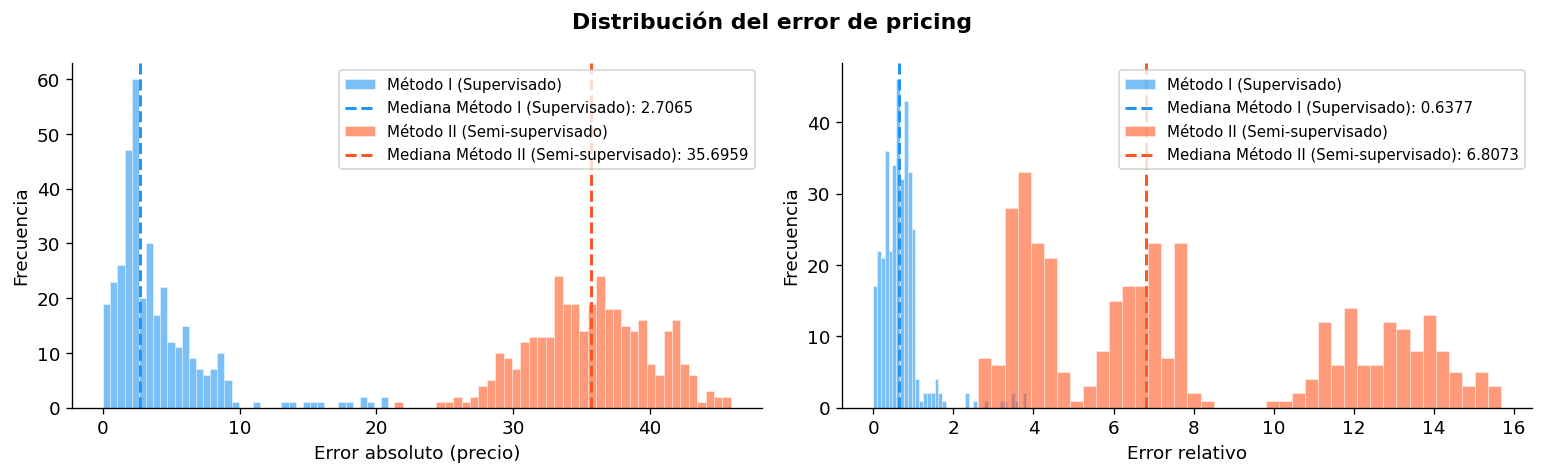

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, xlabel in zip(
    axes,
    ['abs_error', 'rel_error'],
    ['Error absoluto (precio)', 'Error relativo'],
):
    for method_id, label in METHOD_LABELS.items():
        subset = df[df['method'] == method_id][col]
        ax.hist(
            subset, bins=40, alpha=0.6, label=label,
            color=PALETTE[method_id], edgecolor='white', linewidth=0.4
        )
        ax.axvline(subset.median(), color=PALETTE[method_id], lw=1.8, linestyle='--',
                   label=f'Mediana {label}: {subset.median():.4f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

fig.suptitle('Distribución del error de pricing', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Error vs. tamaño de dataset

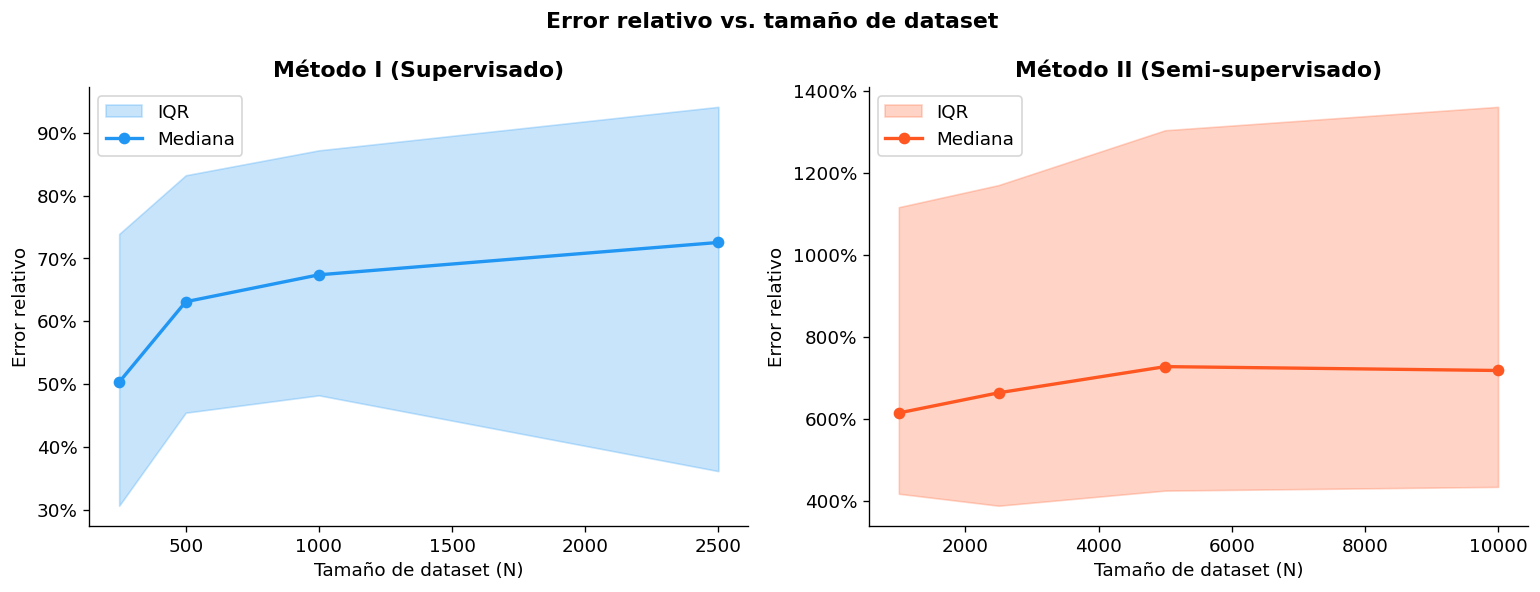

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, method_id in zip(axes, [1, 2]):
    sub = df[df['method'] == method_id]
    sizes = sorted(sub['n_data'].unique())
    medians, q25, q75 = [], [], []
    for s in sizes:
        vals = sub[sub['n_data'] == s]['rel_error']
        medians.append(vals.median())
        q25.append(vals.quantile(0.25))
        q75.append(vals.quantile(0.75))

    ax.fill_between(sizes, q25, q75, alpha=0.25, color=PALETTE[method_id], label='IQR')
    ax.plot(sizes, medians, 'o-', color=PALETTE[method_id], lw=2, label='Mediana')
    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.set_xlabel('Tamaño de dataset (N)')
    ax.set_ylabel('Error relativo')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()

fig.suptitle('Error relativo vs. tamaño de dataset', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Error vs. arquitectura del circuito

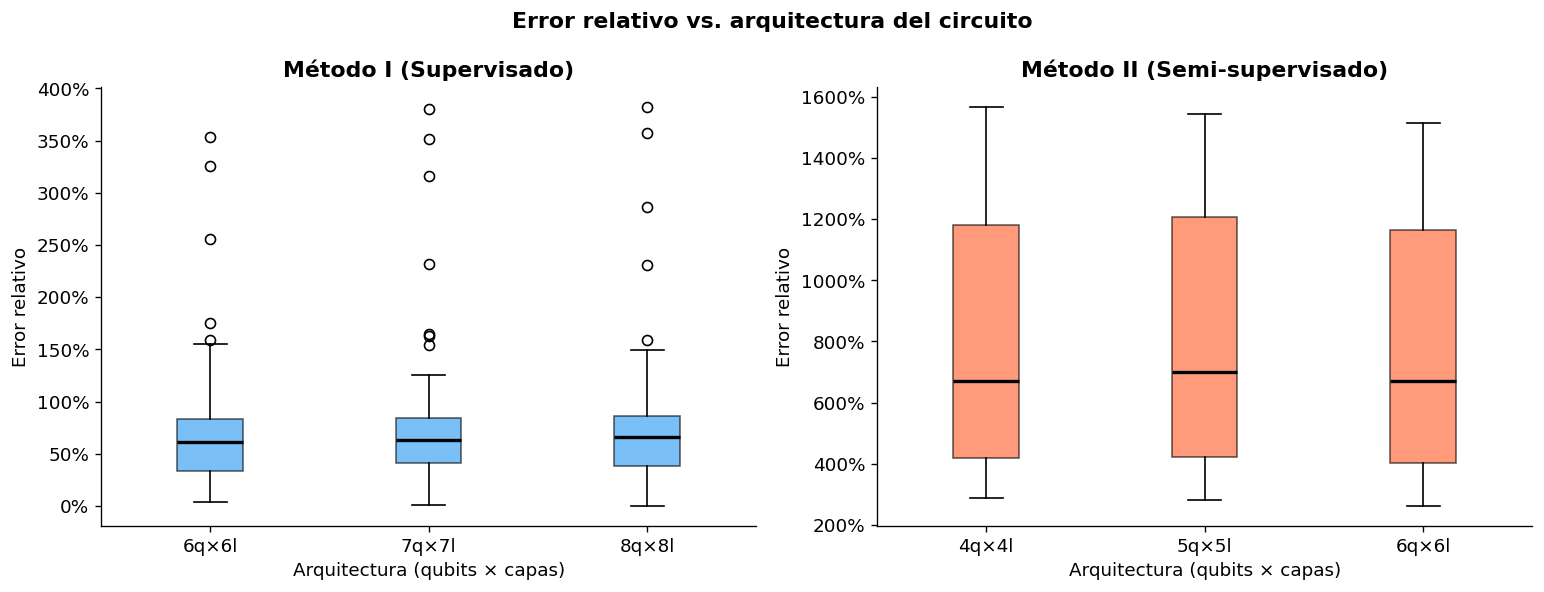

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, method_id in zip(axes, [1, 2]):
    sub = df[df['method'] == method_id]
    archs = sorted(sub['arch'].unique())
    data = [sub[sub['arch'] == a]['rel_error'].values for a in archs]

    bp = ax.boxplot(data, labels=archs, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'lw': 2})
    for patch in bp['boxes']:
        patch.set_facecolor(PALETTE[method_id])
        patch.set_alpha(0.6)

    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.set_xlabel('Arquitectura (qubits × capas)')
    ax.set_ylabel('Error relativo')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Error relativo vs. arquitectura del circuito', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Error vs. precio de ejercicio (K)

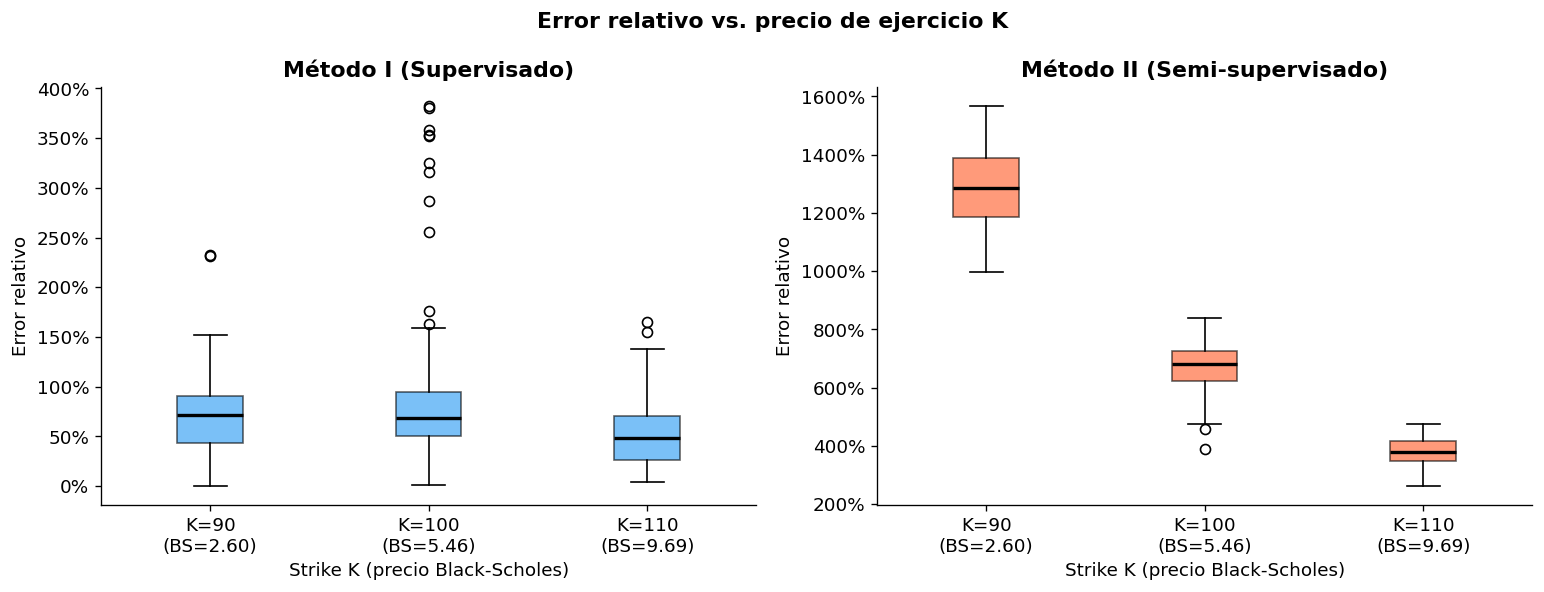

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, method_id in zip(axes, [1, 2]):
    sub = df[df['method'] == method_id]
    strikes = sorted(sub['K'].unique())
    bs_prices = {k: sub[sub['K'] == k]['bs_price'].iloc[0] for k in strikes}

    data = [sub[sub['K'] == k]['rel_error'].values for k in strikes]
    labels = [f"K={k}\n(BS={bs_prices[k]:.2f})" for k in strikes]

    bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'lw': 2})
    for patch in bp['boxes']:
        patch.set_facecolor(PALETTE[method_id])
        patch.set_alpha(0.6)

    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.set_xlabel('Strike K (precio Black-Scholes)')
    ax.set_ylabel('Error relativo')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Error relativo vs. precio de ejercicio K', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Mapa de calor: error mediano por arquitectura × dataset

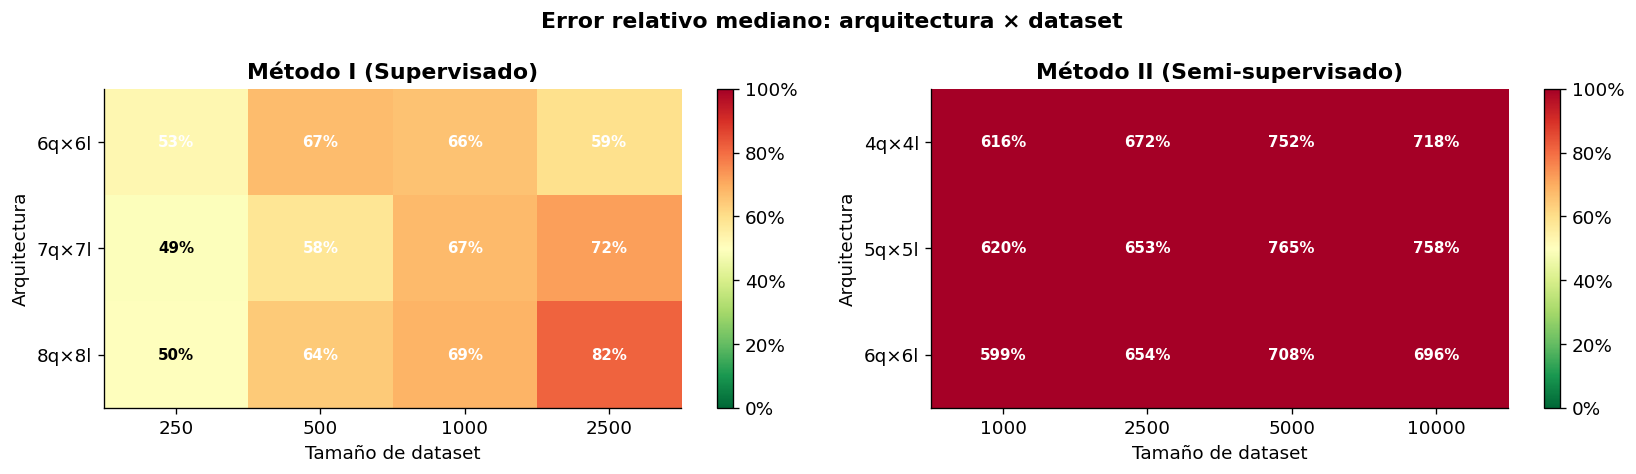

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, method_id in zip(axes, [1, 2]):
    sub = df[df['method'] == method_id]
    pivot = sub.pivot_table(
        values='rel_error', index='arch', columns='n_data', aggfunc='median'
    )
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Tamaño de dataset')
    ax.set_ylabel('Arquitectura')
    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=9,
                    color='white' if val > 0.5 else 'black', fontweight='bold')

    plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(xmax=1))

fig.suptitle('Error relativo mediano: arquitectura × dataset', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Comparación directa entre métodos (misma configuración)

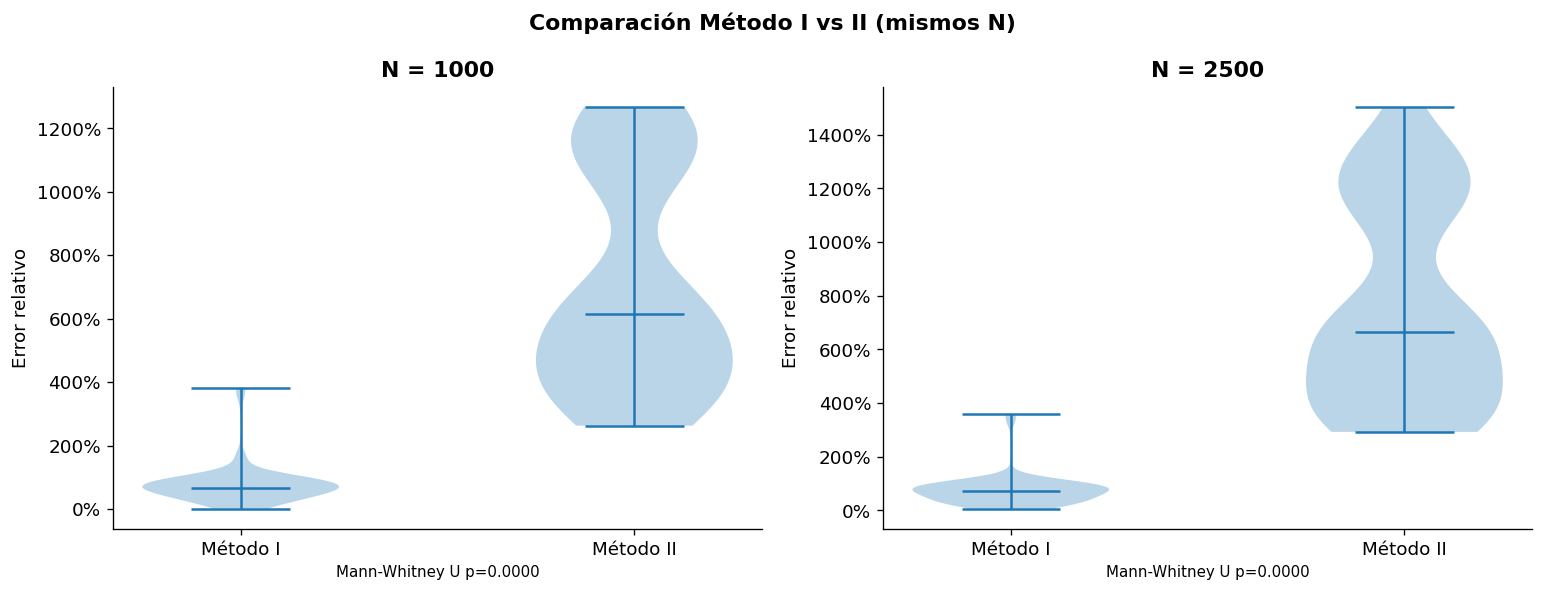

In [42]:
# Configuraciones comunes: K, n_data y repes solapadas
# Método I tiene n_data en [250,500,1000,2500], Método II en [1000,2500,5000,10000]
# Intersección de n_data: [1000, 2500]

COMMON_DATA = [1000, 2500]

m1 = df[(df['method'] == 1) & (df['n_data'].isin(COMMON_DATA))]
m2 = df[(df['method'] == 2) & (df['n_data'].isin(COMMON_DATA))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nd in zip(axes, COMMON_DATA):
    d1 = m1[m1['n_data'] == nd]['rel_error']
    d2 = m2[m2['n_data'] == nd]['rel_error']

    ax.violinplot([d1, d2], positions=[1, 2], showmedians=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Método I', 'Método II'])
    ax.set_title(f'N = {nd}', fontweight='bold')
    ax.set_ylabel('Error relativo')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Test de Mann-Whitney
    stat, pval = stats.mannwhitneyu(d1, d2, alternative='two-sided')
    ax.set_xlabel(f'Mann-Whitney U p={pval:.4f}', fontsize=9)

fig.suptitle('Comparación Método I vs II (mismos N)', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Evolución del entrenamiento (curvas de pérdida)

In [43]:
def load_evolution(method_dir: str, n_runs: int = 10) -> pd.DataFrame:
    """Carga los primeros n_runs archivos evolution.csv de un directorio de método."""
    folders = sorted(glob.glob(os.path.join(method_dir, '*')))
    dfs = []
    for folder in folders[:n_runs]:
        evo_path = os.path.join(folder, 'evolution.csv')
        if not os.path.exists(evo_path):
            continue
        try:
            evo = pd.read_csv(evo_path, sep=';', header=None)
            # Últimas 3 columnas: t, loss, metric_mse
            evo.columns = [f'w{i}' for i in range(len(evo.columns) - 3)] + ['t', 'loss', 'metric_mse']
            evo = evo[evo['t'].notna() & (evo['t'] != evo['t'].shift())].copy()
            evo['run'] = os.path.basename(folder)
            dfs.append(evo[['run', 't', 'loss', 'metric_mse']])
        except Exception:
            pass
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

evo1 = load_evolution(METHOD_I, n_runs=30)
evo2 = load_evolution(METHOD_II, n_runs=30)
print(f'Evoluciones cargadas — M I: {evo1["run"].nunique()} runs | M II: {evo2["run"].nunique()} runs')

Evoluciones cargadas — M I: 30 runs | M II: 30 runs


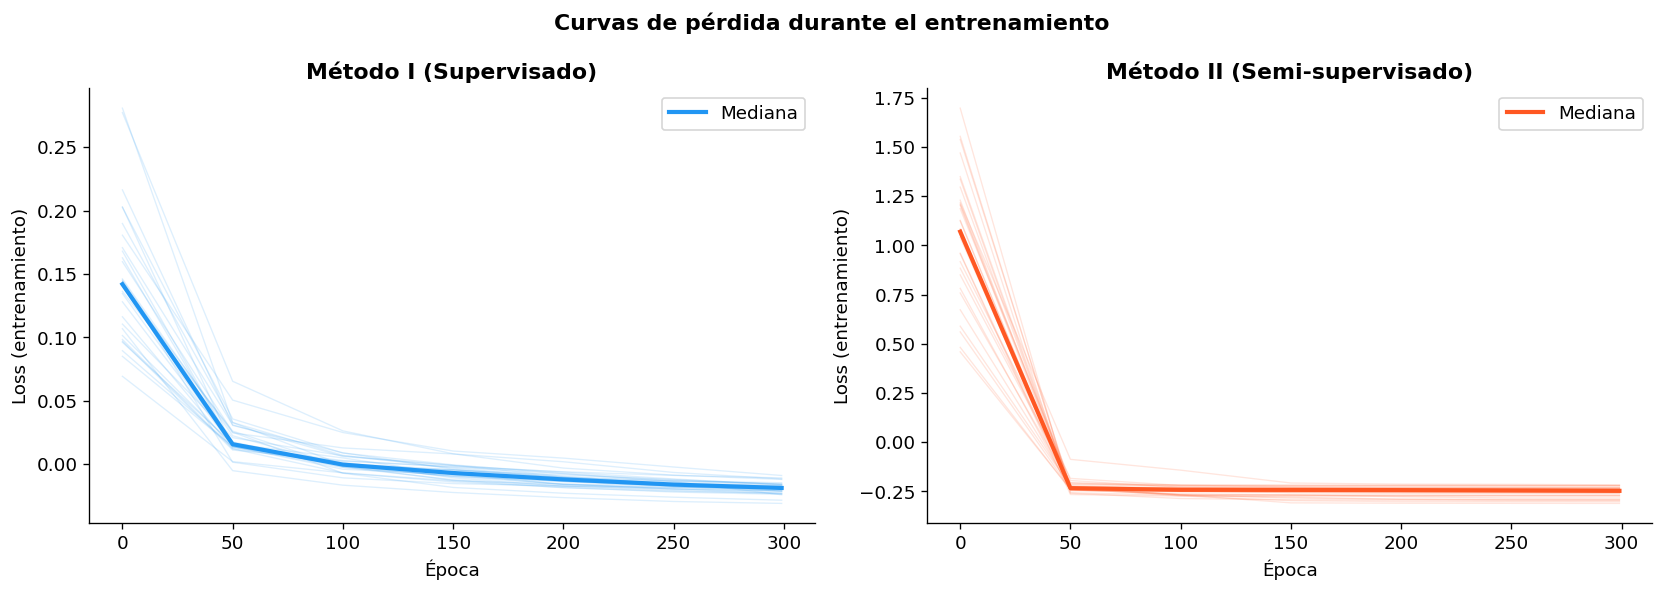

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, evo, method_id, metric in zip(
    axes,
    [evo1, evo2],
    [1, 2],
    ['loss', 'loss'],
):
    color = PALETTE[method_id]
    for run_name, grp in evo.groupby('run'):
        grp_sorted = grp.sort_values('t')
        ax.plot(grp_sorted['t'], grp_sorted[metric], color=color, alpha=0.15, lw=0.8)

    # Mediana por época
    median_curve = evo.groupby('t')[metric].median()
    ax.plot(median_curve.index, median_curve.values, color=color, lw=2.5, label='Mediana')

    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (entrenamiento)')
    ax.legend()

fig.suptitle('Curvas de pérdida durante el entrenamiento', fontweight='bold')
plt.tight_layout()
plt.show()

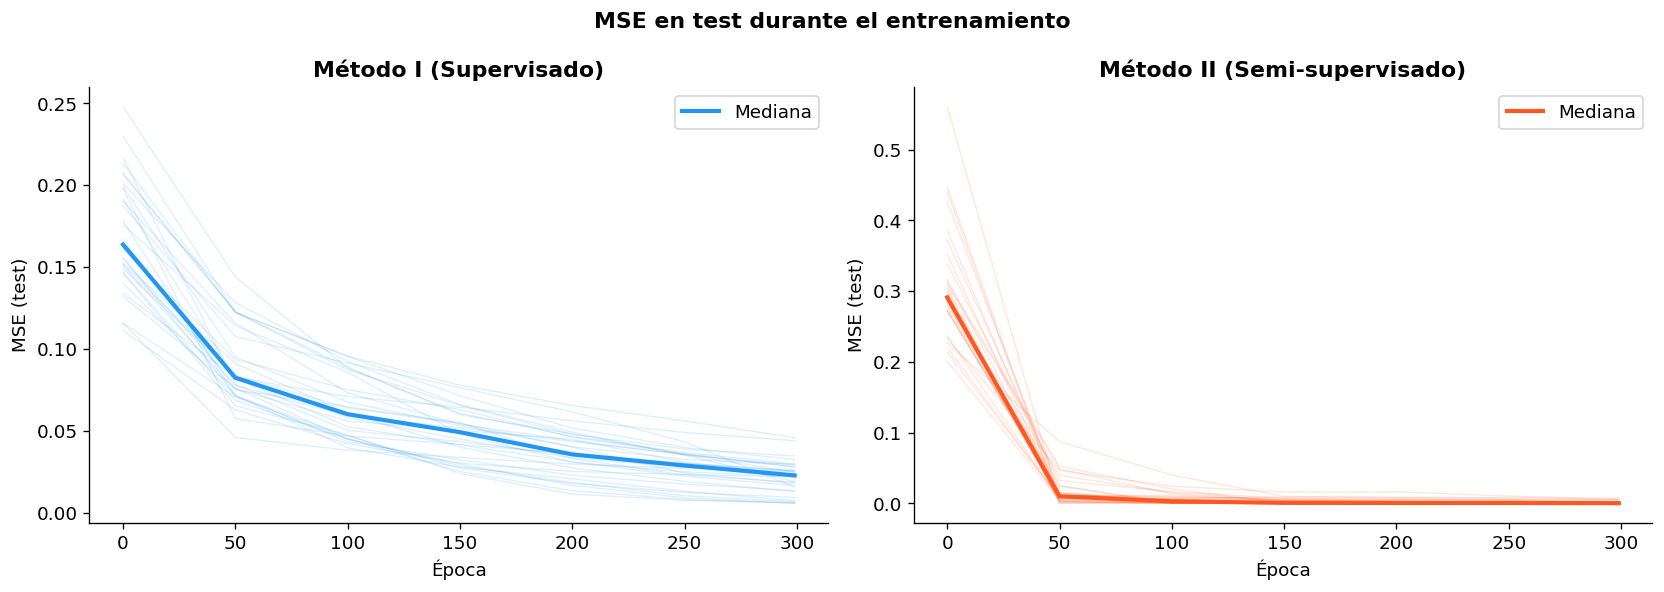

In [45]:
# MSE test por época
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, evo, method_id in zip(axes, [evo1, evo2], [1, 2]):
    color = PALETTE[method_id]
    clean = evo[evo['metric_mse'].notna()]
    for run_name, grp in clean.groupby('run'):
        grp_sorted = grp.sort_values('t')
        ax.plot(grp_sorted['t'], grp_sorted['metric_mse'], color=color, alpha=0.15, lw=0.8)

    median_curve = clean.groupby('t')['metric_mse'].median()
    ax.plot(median_curve.index, median_curve.values, color=color, lw=2.5, label='Mediana')

    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE (test)')
    ax.legend()

fig.suptitle('MSE en test durante el entrenamiento', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Precio estimado vs. precio Black-Scholes

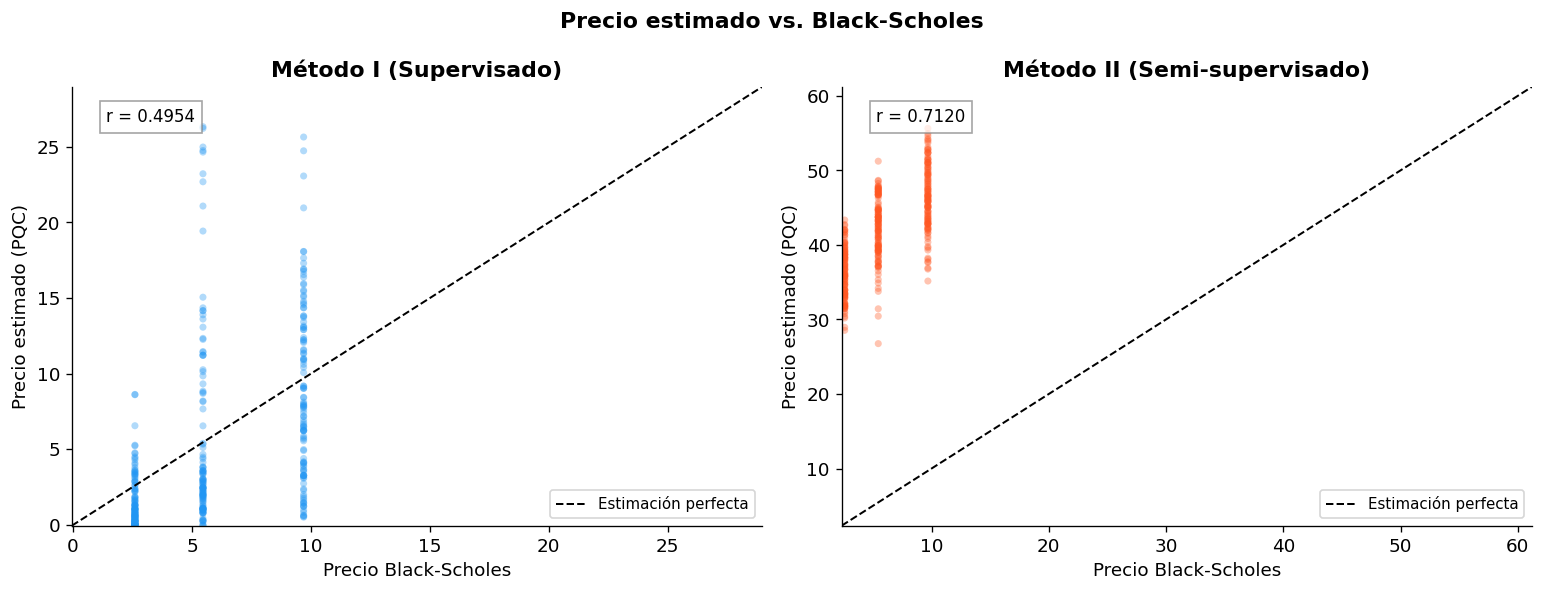

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, method_id in zip(axes, [1, 2]):
    sub = df[df['method'] == method_id]
    ax.scatter(
        sub['bs_price'], sub['estimated_price'],
        c=PALETTE[method_id], alpha=0.35, s=18, edgecolors='none'
    )
    # Línea perfecta
    lims = [
        min(sub['bs_price'].min(), sub['estimated_price'].min()) * 0.9,
        max(sub['bs_price'].max(), sub['estimated_price'].max()) * 1.1,
    ]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Estimación perfecta')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Precio Black-Scholes')
    ax.set_ylabel('Precio estimado (PQC)')
    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.legend(fontsize=9)

    # Coeficiente de correlación
    r, _ = stats.pearsonr(sub['bs_price'], sub['estimated_price'])
    ax.text(0.05, 0.92, f'r = {r:.4f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.7))

fig.suptitle('Precio estimado vs. Black-Scholes', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Mejores configuraciones por método

In [47]:
for method_id in [1, 2]:
    print(f'\n=== {METHOD_LABELS[method_id]} ===')
    sub = df[df['method'] == method_id]

    best_cfg = (
        sub.groupby(['arch', 'n_data', 'K'])
        .agg(
            abs_err_median = ('abs_error', 'median'),
            rel_err_median = ('rel_error', 'median'),
            rel_err_std    = ('rel_error', 'std'),
            n_runs         = ('rep', 'count'),
        )
        .reset_index()
        .sort_values('rel_err_median')
        .head(10)
    )
    best_cfg['rel_err_median'] = best_cfg['rel_err_median'].map('{:.2%}'.format)
    best_cfg['rel_err_std']    = best_cfg['rel_err_std'].map('{:.2%}'.format)
    best_cfg['abs_err_median'] = best_cfg['abs_err_median'].map('{:.4f}'.format)
    print(best_cfg.to_string(index=False))


=== Método I (Supervisado) ===
 arch  n_data   K abs_err_median rel_err_median rel_err_std  n_runs
8q×8l    2500 110         2.2138         22.84%      20.97%      10
8q×8l     250 110         2.2164         22.87%      16.90%      10
6q×6l    2500 110         2.9770         30.72%      17.55%      10
6q×6l     250 110         3.1924         32.94%      21.22%      10
7q×7l     250 110         3.4684         35.79%      18.39%      10
7q×7l    2500 110         3.7326         38.51%      32.58%      10
7q×7l     500  90         1.3332         51.30%      21.09%      10
6q×6l     250  90         1.4207         54.67%      39.48%      10
6q×6l     500  90         1.4279         54.95%      33.97%      10
7q×7l     250 100         3.0881         56.56%      87.06%      10

=== Método II (Semi-supervisado) ===
 arch  n_data   K abs_err_median rel_err_median rel_err_std  n_runs
4q×4l    1000 110        33.8744        349.50%      54.16%      10
6q×6l    2500 110        34.7801        358.85

## 12. Variabilidad entre repeticiones (semillas)

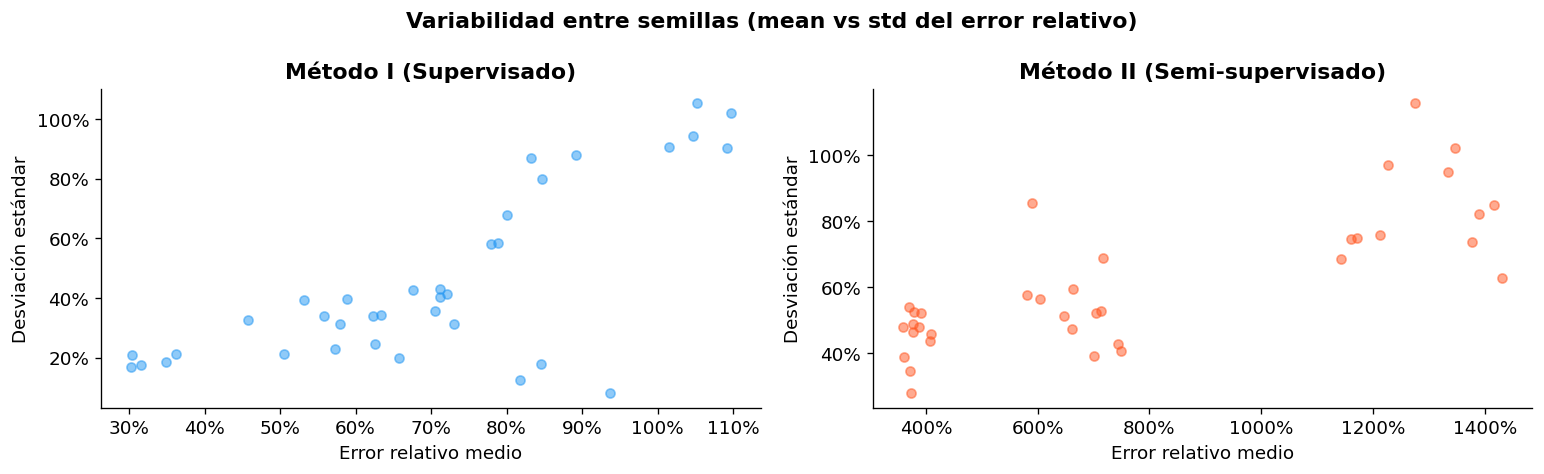


Configuración más estable (menor std):
  M1 | arch=8q×8l | N=2500 | K=90 | mean=93.71% | std=8.07%
  M2 | arch=5q×5l | N=2500 | K=110 | mean=373.56% | std=27.96%


In [48]:
variability = (
    df.groupby(['method', 'arch', 'n_data', 'K'])
    ['rel_error']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)
variability.columns = ['method', 'arch', 'n_data', 'K', 'mean', 'std', 'min', 'max']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, method_id in zip(axes, [1, 2]):
    sub = variability[variability['method'] == method_id]
    ax.scatter(sub['mean'], sub['std'], color=PALETTE[method_id], alpha=0.5, s=30)
    ax.set_xlabel('Error relativo medio')
    ax.set_ylabel('Desviación estándar')
    ax.set_title(METHOD_LABELS[method_id], fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Variabilidad entre semillas (mean vs std del error relativo)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nConfiguración más estable (menor std):')
for method_id in [1, 2]:
    row = variability[variability['method'] == method_id].nsmallest(1, 'std').iloc[0]
    print(f'  M{int(row.method)} | arch={row.arch} | N={int(row.n_data)} | K={int(row.K)}'
          f' | mean={row["mean"]:.2%} | std={row["std"]:.2%}')

## 13. Resumen estadístico final

## 14. Figura 5: Convergencia de precios estimados

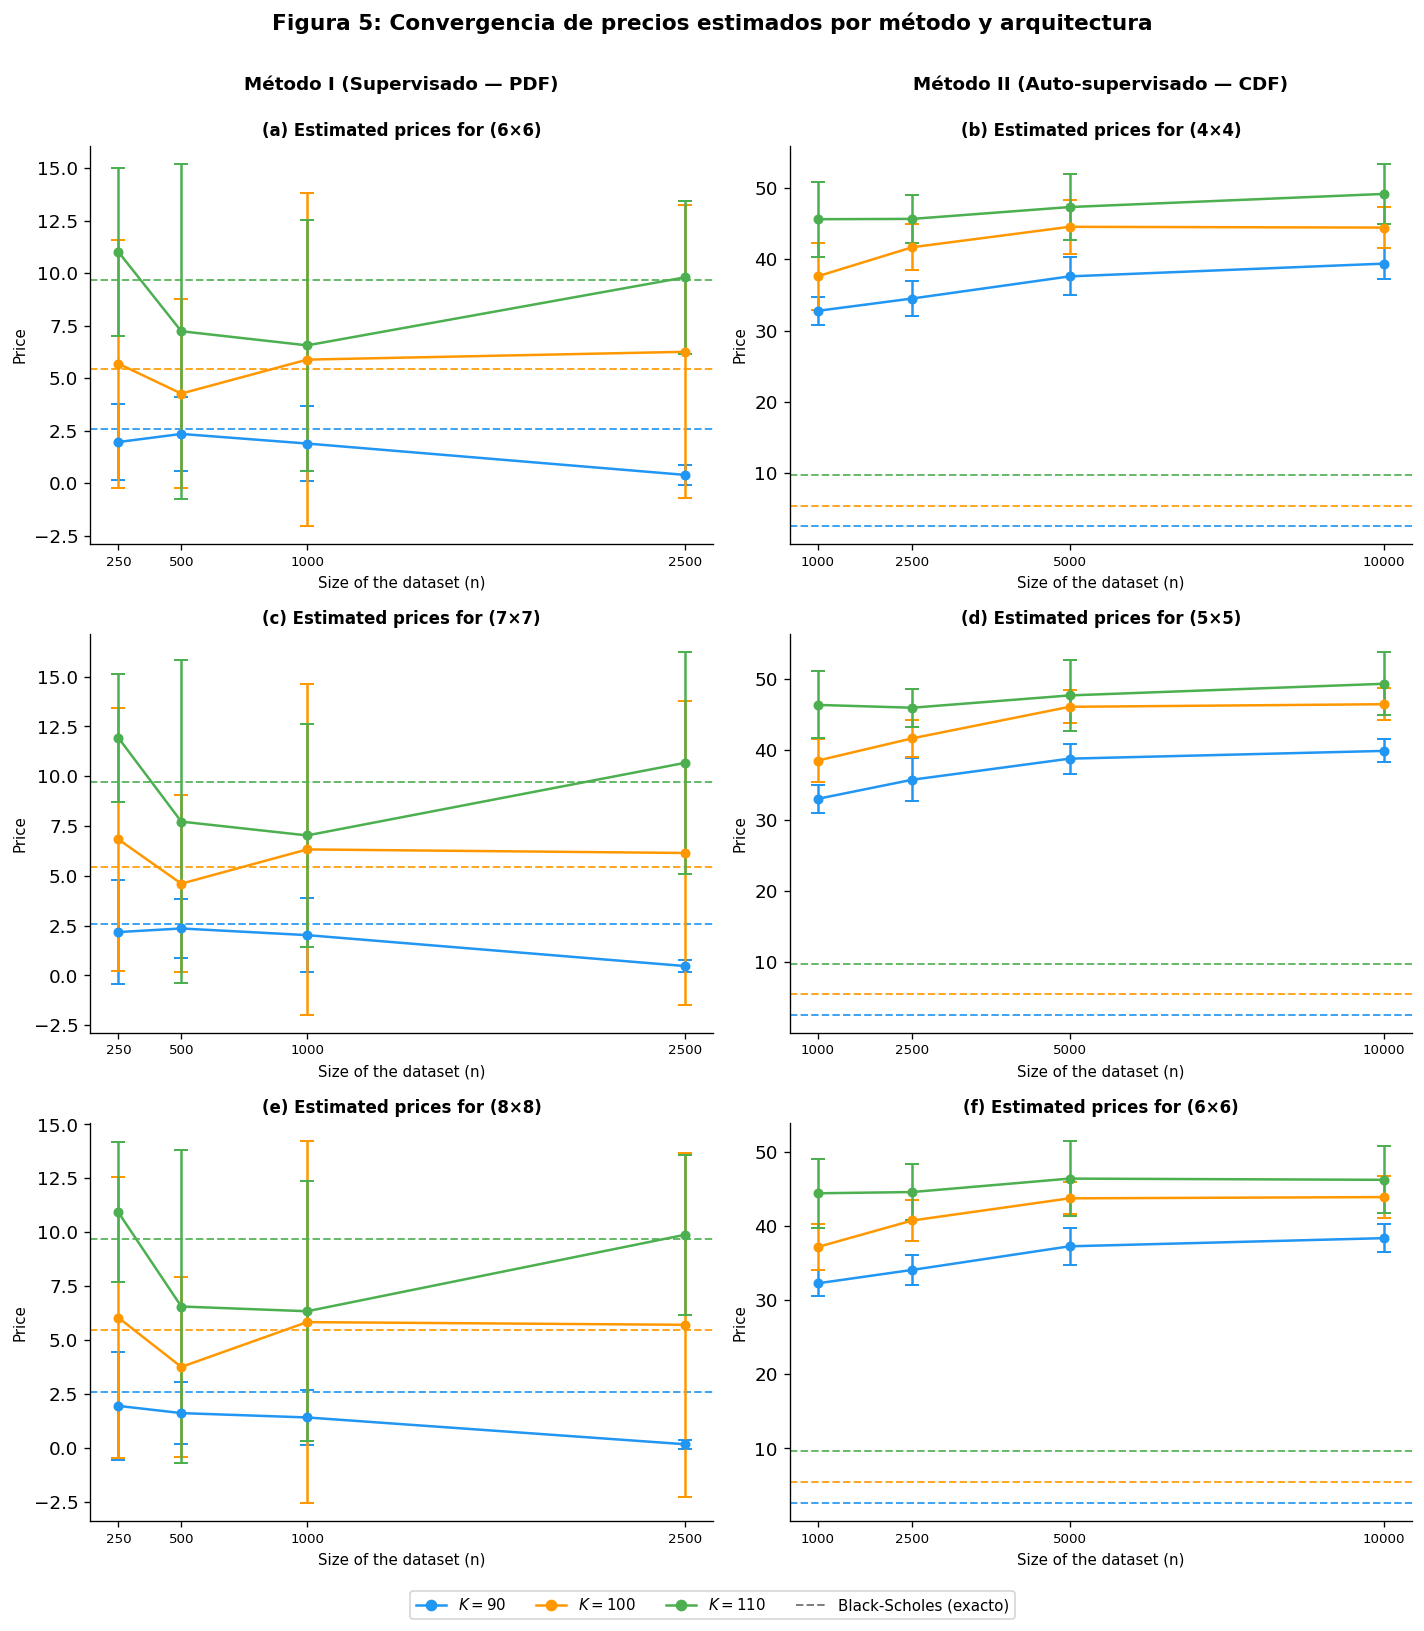

In [49]:
# ── Figura 5: Convergencia de precios estimados por Método y Arquitectura ──
#
# Cuadrícula 3×2:
#   Columna izquierda → Método I  (Supervisado   - PDF): arqs. (6×6), (7×7), (8×8)
#   Columna derecha   → Método II (Auto-supervisado - CDF): arqs. (4×4), (5×5), (6×6)

K_COLORS = {90: '#2196F3', 100: '#FF9800', 110: '#4CAF50'}   # azul, naranja, verde
K_LABELS = {90: r'$K=90$',  100: r'$K=100$',  110: r'$K=110$'}
STRIKES  = [90, 100, 110]

# (method_id, n_qubits, n_layers, panel_letter, arch_str)
configs = [
    (1, 6, 6, 'a', '(6×6)'),
    (2, 4, 4, 'b', '(4×4)'),
    (1, 7, 7, 'c', '(7×7)'),
    (2, 5, 5, 'd', '(5×5)'),
    (1, 8, 8, 'e', '(8×8)'),
    (2, 6, 6, 'f', '(6×6)'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharey=False)
fig.subplots_adjust(hspace=0.48, wspace=0.30)

for idx, (method_id, nq, nl, letter, arch_str) in enumerate(configs):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    sub = df[
        (df['method']   == method_id) &
        (df['n_qubits'] == nq)        &
        (df['n_layers'] == nl)
    ]
    sizes = sorted(sub['n_data'].unique())

    for k in STRIKES:
        color = K_COLORS[k]
        ksub  = sub[sub['K'] == k]

        grp   = ksub.groupby('n_data')['estimated_price']
        means = grp.mean()
        stds  = grp.std()

        ax.errorbar(
            means.index.values, means.values, yerr=stds.values,
            fmt='o-', color=color, capsize=4, capthick=1.2,
            lw=1.5, markersize=5, label=K_LABELS[k],
        )

        # Línea de referencia Black-Scholes (punteada, mismo color)
        bs_val = ksub['bs_price'].iloc[0]
        ax.axhline(bs_val, color=color, linestyle='--', lw=1.2, alpha=0.85)

    ax.set_title(f'({letter}) Estimated prices for {arch_str}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Size of the dataset (n)', fontsize=9)
    ax.set_ylabel('Price', fontsize=9)

    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes], fontsize=8)

# Cabeceras de columna
for col_idx, col_title in enumerate([
    'Método I (Supervisado — PDF)',
    'Método II (Auto-supervisado — CDF)',
]):
    axes[0, col_idx].annotate(
        col_title, xy=(0.5, 1.14), xycoords='axes fraction',
        ha='center', fontsize=11, fontweight='bold',
    )

# Leyenda compartida en la parte inferior
handles = [
    Line2D([0], [0], color=K_COLORS[k], marker='o', lw=1.5, label=K_LABELS[k])
    for k in STRIKES
]
handles.append(
    Line2D([0], [0], color='gray', linestyle='--', lw=1.2, label='Black-Scholes (exacto)')
)
fig.legend(
    handles=handles, loc='lower center', ncol=4, fontsize=9,
    bbox_to_anchor=(0.5, -0.025), frameon=True,
)

fig.suptitle(
    'Figura 5: Convergencia de precios estimados por método y arquitectura',
    fontweight='bold', fontsize=13, y=1.01,
)

plt.tight_layout()
plt.show()


In [50]:
print("═" * 65)
print("RESUMEN ESTADÍSTICO FINAL")
print("═" * 65)

for method_id in [1, 2]:
    sub = df[df["method"] == method_id]
    print(f"\n{METHOD_LABELS[method_id]}")
    print(f"  Experimentos        : {len(sub)}")
    print(f"  Error relativo:")
    print(f"    Media             : {sub['rel_error'].mean():.2%}")
    print(f"    Mediana           : {sub['rel_error'].median():.2%}")
    print(f"    Desv. estándar    : {sub['rel_error'].std():.2%}")
    print(f"    P10               : {sub['rel_error'].quantile(0.1):.2%}")
    print(f"    P90               : {sub['rel_error'].quantile(0.9):.2%}")
    print(f"    Mínimo            : {sub['rel_error'].min():.2%}")
    print(f"    Máximo            : {sub['rel_error'].max():.2%}")
    print(f"  Error absoluto:")
    print(f"    Media             : {sub['abs_error'].mean():.4f}")
    print(f"    Mediana           : {sub['abs_error'].median():.4f}")
    print(f"  MSE final mediano   : {sub['final_mse'].median():.6f}")

print()
# Test estadístico global
d1 = df[df["method"] == 1]["rel_error"]
d2 = df[df["method"] == 2]["rel_error"]
stat, pval = stats.mannwhitneyu(d1, d2, alternative="two-sided")
print(f"Test Mann-Whitney U (M I vs M II): U={stat:.0f}, p={pval:.4e}")
if pval < 0.05:
    mejor = "Método I" if d1.median() < d2.median() else "Método II"
    print(f"  → Diferencia estadísticamente significativa (α=0.05). Mejor mediana: {mejor}")
else:
    print("  → No hay diferencia estadísticamente significativa (α=0.05).")
print("═" * 65)

═════════════════════════════════════════════════════════════════
RESUMEN ESTADÍSTICO FINAL
═════════════════════════════════════════════════════════════════

Método I (Supervisado)
  Experimentos        : 360
  Error relativo:
    Media             : 69.64%
    Mediana           : 63.77%
    Desv. estándar    : 55.18%
    P10               : 18.59%
    P90               : 100.21%
    Mínimo            : 0.30%
    Máximo            : 382.35%
  Error absoluto:
    Media             : 3.8665
    Mediana           : 2.7065
  MSE final mediano   : 0.028906

Método II (Semi-supervisado)
  Experimentos        : 360
  Error relativo:
    Media             : 781.29%
    Mediana           : 680.73%
    Desv. estándar    : 390.63%
    P10               : 355.02%
    P90               : 1373.14%
    Mínimo            : 262.69%
    Máximo            : 1567.55%
  Error absoluto:
    Media             : 35.7146
    Mediana           : 35.6959
  MSE final mediano   : 0.000493

Test Mann-Whitney U (M 